Решить задачу object detection при помощи SSD на датасете https://github.com/Shenggan/BCCD_Dataset

---

# Оbject detection на BCCD: тонкая настройка SSD300 VGG16

Используется torchvision.models.detection.ssd300_vgg16 на BCCD со следующими параметрами:

классы: эритроциты, лейкоциты, тромбоциты (+ фон)\
фиксированное разделение: train/val/test \
потери: L = L_conf + alpha * L_loc с настройкой alpha (комбинация Localization loss и Confidence loss)\
метрика: mAP в стиле COCO @[0.5:0.95] через torchmetrics.

In [16]:
!pip install -q torchmetrics pycocotools

In [17]:
import os
import copy
import time
import random
import math
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import v2 as T
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings("ignore")

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Конфигурация

Порядок выполнения:
1) настройка набора данных/разделения и стратификация
2) вспомогательные функции для модели + обучения/оценки
3) 5-fold кросс-валидация для выбора гиперпараметров
4) итоговое полное обучение на обучающей и валидационной выборках
5) оценка и визуализация нетронутой тестовой выборки

In [20]:
# -----------------------------------------------------------------------------
# Блок глобальной конфигурации
# Этот блок задает все ключевые константы и управляет воспроизводимостью.
# -----------------------------------------------------------------------------

# фиксируем случайность для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset path in your Colab Drive
base_dir = '/content/drive/.../BCCD'
base_dir = Path(base_dir)

# определяем кодировку классов для SSD (0 всегда фон, поэтому объекты начинаются с 1).
CLASS_TO_IDX = {'RBC': 1, 'WBC': 2, 'Platelets': 3}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES = 4  # 3 foreground + background

# Cross-validation настройки
# кандидаты для веса локализационного loss в формуле L = L_conf + alpha * L_loc.
ALPHAS = [0.5, 1.0, 1.5, 2.0]
# кандидаты порога confidence, выбираемые на CV.
SCORE_THR_CANDIDATES = [0.03, 0.05, 0.10]
# количество фолдов для кросс-валидации на объединенном train+val
K_FOLDS = 5
# количество эпох на фолд для кросс-валидации для подбора гиперпараметров
CV_EPOCHS = 4
# количество эпох для финального обучения (train+val)
FINAL_EPOCHS = 8
# количество эпох с замороженным backbone (стабилизация head-а).
WARMUP_EPOCHS = 1
# количество эпох c отсутствием улучшений на fold-val для ранней остановки.
PATIENCE = 2

BATCH_SIZE = 4
NUM_WORKERS = 2
LR_WARMUP = 2e-4
LR_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4

TRAIN_BATCH_LIMIT = None
VAL_BATCH_LIMIT = None

# параметры постобработки внутри SSD
SCORE_THR_VIS = 0.2
SCORE_THR_EVAL = 0.05
NMS_IOU_THR = 0.45
DETECTIONS_PER_IMG = 200

# параметры для для читаемой визуализации
VIS_CLASS_THRESH = {1: 0.35, 2: 0.35, 3: 0.10}
VIS_MAX_DETECTIONS = 50
CLASS_COLORS = {1: 'red', 2: 'lime', 3: 'cyan'}

print('Base dir exists:', base_dir.exists())
print('Device:', device)

Base dir exists: True
Device: cuda


### Заметки по настройкам

- Объекты с `difficult=1` исключаются как из обучения, так и из оценки, чтобы избежать обучения/оценки на неоднозначных метках (практика VOC).
- Усеченные (truncated) объекты сохраняются, поскольку частично видимые клетки повышают устойчивость к случаям краев/окклюзии.
- Битые рамки (`xmin>=xmax` или `ymin>=ymax`) удаляются для обеспечения корректности аннотаций.
- Тестовые данные остаются неизменным до самого конца.
- Данные из обучающей и валидационной выборок объединяются в 5-кратный стратифицированный пул кросс-валидации.
- Этап кросс-валидации включает 4 эпохи на каждый фолд для выбора гиперпараметров; финальный этап полного обучения включает 8 эпох на всех 292 изображениях (train+val).
- После прогрева (warm-up) используется `CosineAnnealingLR`, поскольку плавное затухание LR обычно более стабильно, чем резкие ступенчатые падения на небольших наборах данных.

In [21]:
def read_split_ids(split_file: Path):
    with open(split_file, 'r') as f:
        return [line.strip() for line in f if line.strip()]


def parse_voc_xml(xml_path: Path, class_to_idx: dict, drop_difficult: bool = True):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)

    boxes, labels, areas, iscrowd = [], [], [], []
    stats = {'broken': 0, 'difficult': 0, 'unknown_class': 0}

    for obj in root.findall('object'):
        cls_name = obj.find('name').text.strip()
        difficult_tag = obj.find('difficult')
        difficult = int(difficult_tag.text) if difficult_tag is not None else 0

        if cls_name not in class_to_idx:
            stats['unknown_class'] += 1
            continue

        if drop_difficult and difficult == 1:
            stats['difficult'] += 1
            continue

        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        xmin = max(0.0, min(xmin, width - 1))
        ymin = max(0.0, min(ymin, height - 1))
        xmax = max(0.0, min(xmax, width - 1))
        ymax = max(0.0, min(ymax, height - 1))

        if xmin >= xmax or ymin >= ymax:
            stats['broken'] += 1
            continue

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(class_to_idx[cls_name])
        areas.append((xmax - xmin) * (ymax - ymin))
        iscrowd.append(0)

    target = {
        'boxes': torch.tensor(boxes, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64),
        'area': torch.tensor(areas, dtype=torch.float32),
        'iscrowd': torch.tensor(iscrowd, dtype=torch.int64),
    }

    if target['boxes'].numel() == 0:
        target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
        target['labels'] = torch.zeros((0,), dtype=torch.int64)
        target['area'] = torch.zeros((0,), dtype=torch.float32)
        target['iscrowd'] = torch.zeros((0,), dtype=torch.int64)

    return target, stats


def get_image_class_counts(xml_path: Path, class_to_idx: dict):
    target, _ = parse_voc_xml(xml_path, class_to_idx, drop_difficult=True)
    labels = target['labels'].tolist()
    counts = {1: 0, 2: 0, 3: 0}
    for lbl in labels:
        if lbl in counts:
            counts[lbl] += 1
    return counts


class BCCDDataset(Dataset):
    def __init__(self, root_dir: Path, class_to_idx: dict, split: str = None, image_ids=None, transforms=None, drop_difficult=True):
        self.root_dir = Path(root_dir)
        self.class_to_idx = class_to_idx
        self.transforms = transforms
        self.drop_difficult = drop_difficult

        if (split is None) == (image_ids is None):
            raise ValueError('Provide exactly one of: split or image_ids')

        if split is not None:
            split_path = self.root_dir / 'ImageSets' / 'Main' / f'{split}.txt'
            self.ids = read_split_ids(split_path)
        else:
            self.ids = list(image_ids)

        self.images_dir = self.root_dir / 'JPEGImages'
        self.ann_dir = self.root_dir / 'Annotations'

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img_path = self.images_dir / f'{image_id}.jpg'
        xml_path = self.ann_dir / f'{image_id}.xml'

        image = read_image(str(img_path)).float() / 255.0
        target, _ = parse_voc_xml(xml_path, self.class_to_idx, drop_difficult=self.drop_difficult)
        target['image_id'] = torch.tensor([idx], dtype=torch.int64)

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


def get_transforms(train: bool = False):
    tr = [T.ToDtype(torch.float32, scale=False)]
    if train:
        tr.append(T.RandomHorizontalFlip(p=0.5))
    return T.Compose(tr)

### Подготовка сплитов и стратификации для CV


- `test` остается изолированным и не используется при выборе параметров.
- Для CV объединяем только `train+val` в `cv_pool_ids`.
- Стратификация строится не по одному классу, а по составному признаку:
  - наличие классов `RBC/WBC/Platelets`.
- Редкие страты аггрегируются, чтобы корректно работал `KFold=5`.


In [22]:
train_ids = read_split_ids(base_dir / 'ImageSets' / 'Main' / 'train.txt')
val_ids = read_split_ids(base_dir / 'ImageSets' / 'Main' / 'val.txt')
test_ids = read_split_ids(base_dir / 'ImageSets' / 'Main' / 'test.txt')

cv_pool_ids = train_ids + val_ids  # 292 samples for cross-validation

# Test set remains untouched until final evaluation.
test_ds = BCCDDataset(base_dir, CLASS_TO_IDX, image_ids=test_ids, transforms=get_transforms(train=False), drop_difficult=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print(f'CV pool / Test sizes: {len(cv_pool_ids)} / {len(test_ds)}')

# Stratification label from class-presence and coarse density bins (focus on Platelets balance)
def build_strata(image_ids):
    raw = []
    for image_id in image_ids:
        xml_path = base_dir / 'Annotations' / f'{image_id}.xml'
        cnt = get_image_class_counts(xml_path, CLASS_TO_IDX)

        p_rbc = int(cnt[1] > 0)
        p_wbc = int(cnt[2] > 0)
        p_plt = int(cnt[3] > 0)

        # coarse bins to preserve images with richer platelet content across folds
        plt_bin = min(cnt[3] // 8, 3)
        rbc_bin = min(cnt[1] // 25, 3)
        raw.append(f'{p_rbc}{p_wbc}{p_plt}_{plt_bin}_{rbc_bin}')

    counts = pd.Series(raw).value_counts()
    # Rare strata are merged by presence-only code to satisfy 5-fold constraints.
    merged = []
    for s in raw:
        if counts[s] < K_FOLDS:
            merged.append(s.split('_')[0])
        else:
            merged.append(s)
    return np.array(merged)

strata_labels = build_strata(cv_pool_ids)
print('Unique strata:', len(np.unique(strata_labels)))

# Quick annotation sanity report over full pool + test
report = defaultdict(int)
for image_id in cv_pool_ids + test_ids:
    _, st = parse_voc_xml(base_dir / 'Annotations' / f'{image_id}.xml', CLASS_TO_IDX, drop_difficult=True)
    for k, v in st.items():
        report[k] += v
print('Annotation filtering stats:', dict(report))

CV pool / Test sizes: 292 / 72
Unique strata: 7
Annotation filtering stats: {'broken': 2, 'difficult': 0, 'unknown_class': 0}


### Сборка SSD-модели и оптимизатора

- Загружается предобученный `ssd300_vgg16` (COCO weights).
- Head модели пересоздается под число классов BCCD (`NUM_CLASSES=4`, включая фон).
- Каналы head берутся из исходной архитектуры SSD, чтобы не ломать согласованность с anchor-конфигурацией.
- `set_backbone_trainable` используется для warm-up/fine-tune режима:
  - warm-up: backbone frozen;
  - fine-tuning: backbone unfrozen.
- Оптимизатор `AdamW` используется для стабильного fine-tune на небольшом датасете.


In [23]:
def build_model(num_classes=NUM_CLASSES):
    weights = SSD300_VGG16_Weights.DEFAULT
    model = ssd300_vgg16(weights=weights)

    # Rebuild SSD heads for BCCD classes (+ background).
    # We reuse the same feature-channel layout as the original pretrained SSD head.
    num_anchors = model.anchor_generator.num_anchors_per_location()
    in_channels = [m.in_channels for m in model.head.classification_head.module_list]

    from torchvision.models.detection.ssd import SSDHead
    model.head = SSDHead(in_channels, num_anchors, num_classes)

    model.to(device)
    model.score_thresh = SCORE_THR_VIS
    model.nms_thresh = NMS_IOU_THR
    model.detections_per_img = DETECTIONS_PER_IMG
    return model


def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable


def get_optimizer(model, lr):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)

### Train/Eval helper-функции

- `evaluate_map`:
  - переводит модель в `eval()`;
  - считает COCO-style mAP через `torchmetrics`;
  - временно выставляет `score_thresh` для сравнения кандидатов порога.
- `evaluate_loss`:
  - использует `model.train()` намеренно, потому что `torchvision` detection-models отдают loss только в train-mode;
  - при этом используется `@torch.no_grad()`, поэтому веса не обновляются.
- `train_one_epoch`:
  - обычный train-шаг с формулой `L_conf + alpha * L_loc`;
  - `batch_limit` оставлен как технический переключатель ускоренных прогонов.


In [24]:
@torch.no_grad()
def evaluate_map(model, loader, score_thr=SCORE_THR_EVAL, batch_limit=None):
    model.eval()
    old_score_thr = model.score_thresh
    model.score_thresh = score_thr

    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=True)

    for b_idx, (images, targets) in enumerate(loader):
        if batch_limit is not None and b_idx >= batch_limit:
            break

        images = [img.to(device) for img in images]
        preds = model(images)

        preds_cpu = []
        for p in preds:
            preds_cpu.append({
                'boxes': p['boxes'].detach().cpu(),
                'scores': p['scores'].detach().cpu(),
                'labels': p['labels'].detach().cpu(),
            })

        targets_cpu = []
        for t in targets:
            targets_cpu.append({
                'boxes': t['boxes'].detach().cpu(),
                'labels': t['labels'].detach().cpu(),
            })

        metric.update(preds_cpu, targets_cpu)

    out = metric.compute()
    model.score_thresh = old_score_thr
    return out


@torch.no_grad()
def evaluate_loss(model, loader, alpha=1.0, batch_limit=None):
    model.train()  # torchvision detection models produce losses in train mode

    loss_sum = 0.0
    steps = 0
    for b_idx, (images, targets) in enumerate(loader):
        if batch_limit is not None and b_idx >= batch_limit:
            break

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        cls_loss = loss_dict.get('classification', torch.tensor(0.0, device=device))
        loc_loss = loss_dict.get('bbox_regression', torch.tensor(0.0, device=device))
        total_loss = cls_loss + alpha * loc_loss

        loss_sum += total_loss.item()
        steps += 1

    return loss_sum / max(steps, 1)


def train_one_epoch(model, loader, optimizer, alpha=1.0, batch_limit=None):
    model.train()
    total_loss = 0.0
    steps = 0

    for b_idx, (images, targets) in enumerate(loader):
        if batch_limit is not None and b_idx >= batch_limit:
            break

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        cls_loss = loss_dict.get('classification', torch.tensor(0.0, device=device))
        loc_loss = loss_dict.get('bbox_regression', torch.tensor(0.0, device=device))
        total = cls_loss + alpha * loc_loss

        optimizer.zero_grad(set_to_none=True)
        total.backward()
        optimizer.step()

        total_loss += total.item()
        steps += 1

    return total_loss / max(steps, 1)

### Основной CV-цикл и финальный full-train


1. Для каждого `alpha` запускается 5-fold стратифицированная CV.
2. Внутри каждого fold:
   - обучаем модель 4 эпохи (warm-up + fine-tune);
   - на валидации проверяем несколько `score_thr`;
   - фиксируем лучший `fold_best_val_map` и соответствующий `fold_best_thr`.
3. После всех fold усредняем метрики по `alpha` и выбираем лучший набор (`best_alpha`, `best_score_thr`).
4. Переобучаем новую модель на всех `train+val` (292) в течение 8 эпох.

Таким образом, hyperparameter selection делается на кросс-валидации, а финальная модель обучается на максимальном доступном train-объеме.


In [25]:
# 5-fold stratified CV on train+val pool, tune alpha + score threshold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

cv_rows = []
cv_history_rows = []

for alpha in ALPHAS:
    print(f"\n===== CV alpha = {alpha} =====")

    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(cv_pool_ids, strata_labels), start=1):
        fold_train_ids = [cv_pool_ids[i] for i in tr_idx]
        fold_val_ids = [cv_pool_ids[i] for i in va_idx]

        fold_train_ds = BCCDDataset(base_dir, CLASS_TO_IDX, image_ids=fold_train_ids, transforms=get_transforms(train=True), drop_difficult=True)
        fold_val_ds = BCCDDataset(base_dir, CLASS_TO_IDX, image_ids=fold_val_ids, transforms=get_transforms(train=False), drop_difficult=True)

        fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
        fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

        model = build_model(NUM_CLASSES)
        set_backbone_trainable(model, trainable=False)
        optimizer = get_optimizer(model, lr=LR_WARMUP)
        scheduler = None

        best_fold_state = None
        best_fold_map = -1.0
        best_fold_thr = SCORE_THR_EVAL
        stale_epochs = 0

        for epoch in range(CV_EPOCHS):
            t0 = time.time()

            if epoch == WARMUP_EPOCHS:
                set_backbone_trainable(model, trainable=True)
                optimizer = get_optimizer(model, lr=LR_FINETUNE)
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=max(1, CV_EPOCHS - WARMUP_EPOCHS)
                )

            tr_loss = train_one_epoch(model, fold_train_loader, optimizer, alpha=alpha, batch_limit=TRAIN_BATCH_LIMIT)
            val_loss = evaluate_loss(model, fold_val_loader, alpha=alpha, batch_limit=VAL_BATCH_LIMIT)

            thr_scores = {}
            for thr in SCORE_THR_CANDIDATES:
                m = evaluate_map(model, fold_val_loader, score_thr=thr, batch_limit=VAL_BATCH_LIMIT)
                thr_scores[thr] = float(m['map'].item())

            epoch_best_thr = max(thr_scores, key=thr_scores.get)
            epoch_best_map = thr_scores[epoch_best_thr]

            if scheduler is not None:
                scheduler.step()

            cv_history_rows.append({
                'fold': fold_idx,
                'alpha': alpha,
                'epoch': epoch + 1,
                'train_loss': tr_loss,
                'val_loss': val_loss,
                'val_map_best_thr': epoch_best_map,
                'best_thr': epoch_best_thr,
            })

            dt = time.time() - t0
            print(
                f"fold={fold_idx}/{K_FOLDS} epoch={epoch+1}/{CV_EPOCHS} "
                f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
                f"best_val_map={epoch_best_map:.4f} thr={epoch_best_thr:.2f} ({dt:.1f}s)"
            )

            if epoch_best_map > best_fold_map:
                best_fold_map = epoch_best_map
                best_fold_thr = epoch_best_thr
                best_fold_state = copy.deepcopy(model.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1

            if stale_epochs >= PATIENCE:
                print(f"early stop fold={fold_idx}, alpha={alpha}")
                break

        cv_rows.append({
            'fold': fold_idx,
            'alpha': alpha,
            'fold_best_val_map': best_fold_map,
            'fold_best_thr': best_fold_thr,
            'fold_train_size': len(fold_train_ds),
            'fold_val_size': len(fold_val_ds),
        })

cv_df = pd.DataFrame(cv_rows)
cv_history_df = pd.DataFrame(cv_history_rows)

cv_alpha_df = (
    cv_df.groupby('alpha', as_index=False)
    .agg(
        mean_val_map=('fold_best_val_map', 'mean'),
        std_val_map=('fold_best_val_map', 'std'),
        mean_best_thr=('fold_best_thr', 'mean')
    )
    .sort_values('mean_val_map', ascending=False)
)

best_alpha = float(cv_alpha_df.iloc[0]['alpha'])
best_cv_map = float(cv_alpha_df.iloc[0]['mean_val_map'])
best_score_thr = float(cv_alpha_df.iloc[0]['mean_best_thr'])

print('\nCV summary (alpha tuning):')
display(cv_alpha_df)
print(f"Selected alpha={best_alpha}, score_thr={best_score_thr:.3f}, mean CV mAP={best_cv_map:.4f}")

# Final full-train on all train+val (292) for 8 epochs
full_train_ds = BCCDDataset(base_dir, CLASS_TO_IDX, image_ids=cv_pool_ids, transforms=get_transforms(train=True), drop_difficult=True)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)

best_model = build_model(NUM_CLASSES)
set_backbone_trainable(best_model, trainable=False)
optimizer = get_optimizer(best_model, lr=LR_WARMUP)
scheduler = None

final_history = {
    'epoch': [],
    'train_loss': [],
}

for epoch in range(FINAL_EPOCHS):
    if epoch == WARMUP_EPOCHS:
        set_backbone_trainable(best_model, trainable=True)
        optimizer = get_optimizer(best_model, lr=LR_FINETUNE)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, FINAL_EPOCHS - WARMUP_EPOCHS)
        )

    tr_loss = train_one_epoch(best_model, full_train_loader, optimizer, alpha=best_alpha, batch_limit=TRAIN_BATCH_LIMIT)

    if scheduler is not None:
        scheduler.step()

    final_history['epoch'].append(epoch + 1)
    final_history['train_loss'].append(tr_loss)
    print(f"final_train epoch={epoch+1}/{FINAL_EPOCHS} train_loss={tr_loss:.4f}")


===== CV alpha = 0.5 =====
fold=1/5 epoch=1/4 train_loss=5.2588 val_loss=3.7110 best_val_map=0.0598 thr=0.03 (26.3s)
fold=1/5 epoch=2/4 train_loss=3.4857 val_loss=2.8849 best_val_map=0.3202 thr=0.03 (31.0s)
fold=1/5 epoch=3/4 train_loss=3.0836 val_loss=2.5167 best_val_map=0.4359 thr=0.03 (31.1s)
fold=1/5 epoch=4/4 train_loss=2.8861 val_loss=2.3481 best_val_map=0.4448 thr=0.03 (30.5s)
fold=2/5 epoch=1/4 train_loss=5.2047 val_loss=3.6922 best_val_map=0.0708 thr=0.03 (23.9s)
fold=2/5 epoch=2/4 train_loss=3.4420 val_loss=2.7707 best_val_map=0.3295 thr=0.03 (32.1s)
fold=2/5 epoch=3/4 train_loss=3.0001 val_loss=2.4157 best_val_map=0.4033 thr=0.03 (30.9s)
fold=2/5 epoch=4/4 train_loss=2.9018 val_loss=2.3239 best_val_map=0.4039 thr=0.03 (29.9s)
fold=3/5 epoch=1/4 train_loss=5.2296 val_loss=3.6431 best_val_map=0.1148 thr=0.03 (24.3s)
fold=3/5 epoch=2/4 train_loss=3.5078 val_loss=3.2428 best_val_map=0.1378 thr=0.03 (32.2s)
fold=3/5 epoch=3/4 train_loss=3.1624 val_loss=2.6366 best_val_map=0.3884

,alpha,mean_val_map,std_val_map,mean_best_thr
3,2.0,0.472441,0.016782,0.03
2,1.5,0.464083,0.007632,0.03
1,1.0,0.426108,0.065817,0.03
0,0.5,0.373776,0.137184,0.03


Selected alpha=2.0, score_thr=0.030, mean CV mAP=0.4724
final_train epoch=1/8 train_loss=7.5983
final_train epoch=2/8 train_loss=5.5290
final_train epoch=3/8 train_loss=4.9344
final_train epoch=4/8 train_loss=4.5085
final_train epoch=5/8 train_loss=4.1884
final_train epoch=6/8 train_loss=3.8602
final_train epoch=7/8 train_loss=3.7129
final_train epoch=8/8 train_loss=3.6600


### Финальная оценка на test

Этот блок выполняется один раз после выбора гиперпараметров и full-train.

- Используется отложенный `test_loader`.
- Считаются основные метрики качества детекции:
  - `test_mAP` = mAP@[0.5:0.95] (главная интегральная метрика). Средняя точность (AP), усредненная по IoU-порогам 0.50, 0.55, ..., 0.95 и по классам. Самая “строгая” и основная интегральная метрика качества детектора;
  - `test_mAP_50` и `test_mAP_75` для оценки при разных строгостях IoU. `test_map_50` - более мягкая метрика: бокс считается хорошим уже при IoU >= 0.5. `test_map_75` - более строгая к локализации: требует более точного совпадения рамок с Ground Truth;
  - `test_mAR_100` как мера recall при ограничении до 100 предсказаний на изображение. Показывает, сколько истинных объектов модель в принципе находит (без акцента на precision)

In [30]:
# Final untouched test evaluation (single run after full-train)
test_metrics = evaluate_map(best_model, test_loader, score_thr=best_score_thr, batch_limit=None)

summary = {
    'k_folds': K_FOLDS,
    'cv_epochs': CV_EPOCHS,
    'final_epochs': FINAL_EPOCHS,
    'best_alpha': best_alpha,
    'best_score_thr': best_score_thr,
    'cv_mean_val_mAP': best_cv_map,
    'test_mAP': float(test_metrics['map'].item()),
    'test_mAP_50': float(test_metrics['map_50'].item()),
    'test_mAP_75': float(test_metrics['map_75'].item()),
    'test_mAR_100': float(test_metrics['mar_100'].item()),
}

summary_df = pd.DataFrame([summary])
summary_df

,k_folds,cv_epochs,final_epochs,best_alpha,best_score_thr,cv_mean_val_mAP,test_mAP,test_mAP_50,test_mAP_75,test_mAR_100
0,5,4,8,2.0,0.03,0.472441,0.529957,0.870238,0.574279,0.634265


In [27]:
# Per-class metrics table
per_class_rows = []
map_pc = test_metrics.get('map_per_class', torch.tensor([]))
mar_pc = test_metrics.get('mar_100_per_class', torch.tensor([]))
classes_pc = test_metrics.get('classes', torch.tensor([]))

for i in range(len(classes_pc)):
    cls_idx = int(classes_pc[i].item())
    if cls_idx == 0:
        continue
    per_class_rows.append({
        'class_id': cls_idx,
        'class_name': IDX_TO_CLASS.get(cls_idx, f'cls_{cls_idx}'),
        'mAP': float(map_pc[i].item()) if len(map_pc) > i else np.nan,
        'mAR_100': float(mar_pc[i].item()) if len(mar_pc) > i else np.nan,
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values('class_id')
per_class_df

,class_id,class_name,mAP,mAR_100
0,1,RBC,0.538261,0.668075
1,2,WBC,0.685313,0.752113
2,3,Platelets,0.366297,0.482609


### Графики динамики обучения и итогов

Что показывают графики:

- Слева: усредненные train/val loss по эпохам CV для лучшего `alpha`.
- По центру: средний CV mAP по эпохам + loss финального full-train.
- Справа: итоговые test-метрики (единственный финальный запуск).

Эти графики нужны, чтобы визуально проверить:
- стабильность CV-обучения;
- отсутствие явной деградации в финальном full-train;
- согласованность CV и test качества.


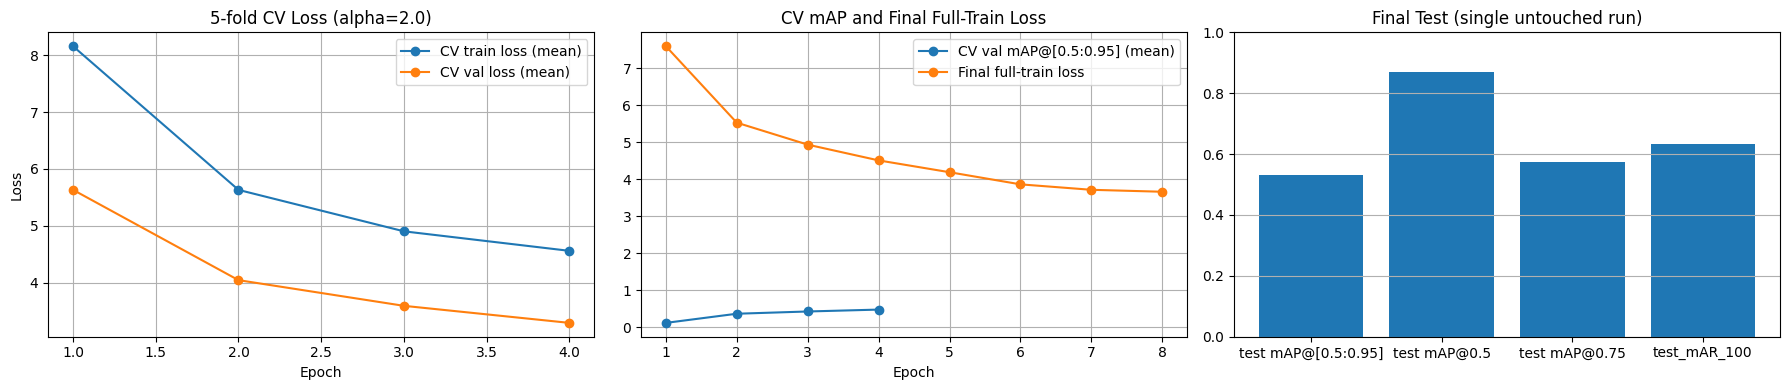

In [28]:
# Curves: CV trend (best alpha) + final full-train + test metrics
best_alpha_history = cv_history_df[cv_history_df['alpha'] == best_alpha].copy()
cv_epoch_mean = (
    best_alpha_history.groupby('epoch', as_index=False)
    .agg(
        train_loss=('train_loss', 'mean'),
        val_loss=('val_loss', 'mean'),
        val_map=('val_map_best_thr', 'mean')
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(cv_epoch_mean['epoch'], cv_epoch_mean['train_loss'], marker='o', label='CV train loss (mean)')
axes[0].plot(cv_epoch_mean['epoch'], cv_epoch_mean['val_loss'], marker='o', label='CV val loss (mean)')
axes[0].set_title(f'5-fold CV Loss (alpha={best_alpha})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(cv_epoch_mean['epoch'], cv_epoch_mean['val_map'], marker='o', label='CV val mAP@[0.5:0.95] (mean)')
axes[1].plot(final_history['epoch'], final_history['train_loss'], marker='o', label='Final full-train loss')
axes[1].set_title('CV mAP and Final Full-Train Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)
axes[1].legend()

axes[2].bar(['test mAP@[0.5:0.95]', 'test mAP@0.5', 'test mAP@0.75', 'test_mAR_100'],
            [summary['test_mAP'], summary['test_mAP_50'], summary['test_mAP_75'], summary['test_mAR_100']])
axes[2].set_title('Final Test (single untouched run)')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

### Визуализация предсказаний на тесте

- показываются предсказанные боксы, класс и confidence;
- применяется class-aware фильтрация по score для читаемости;
- для каждого изображения выводится статичная картинка через Matplotlib/Seaborn.

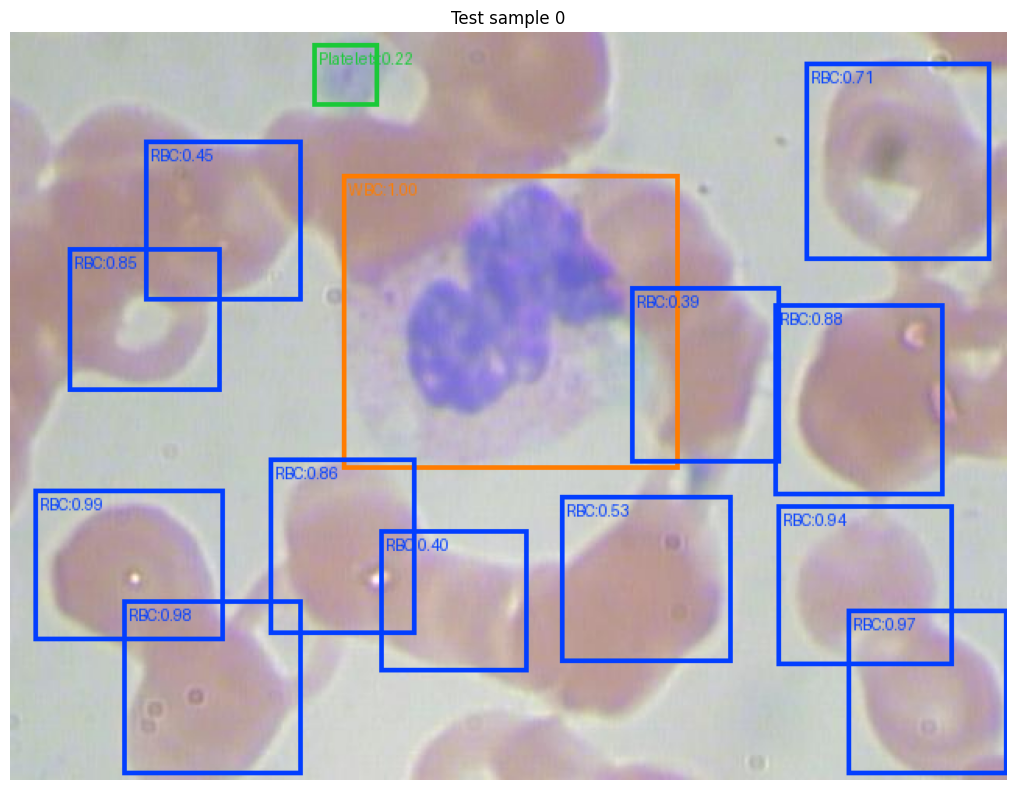

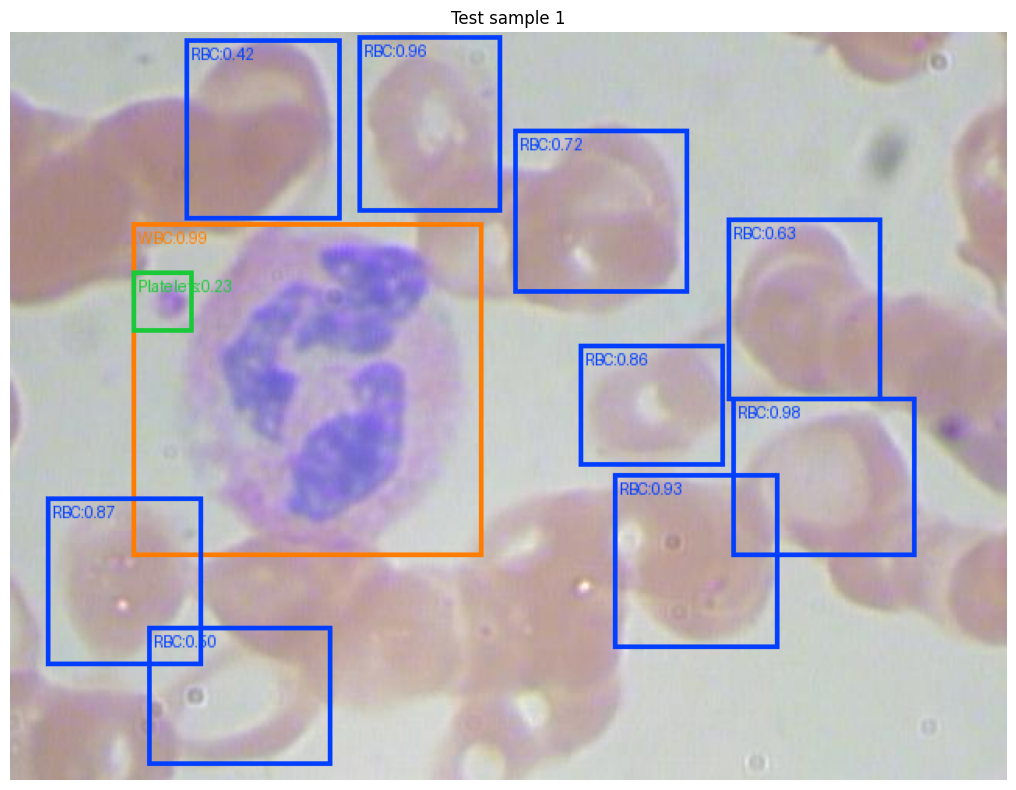

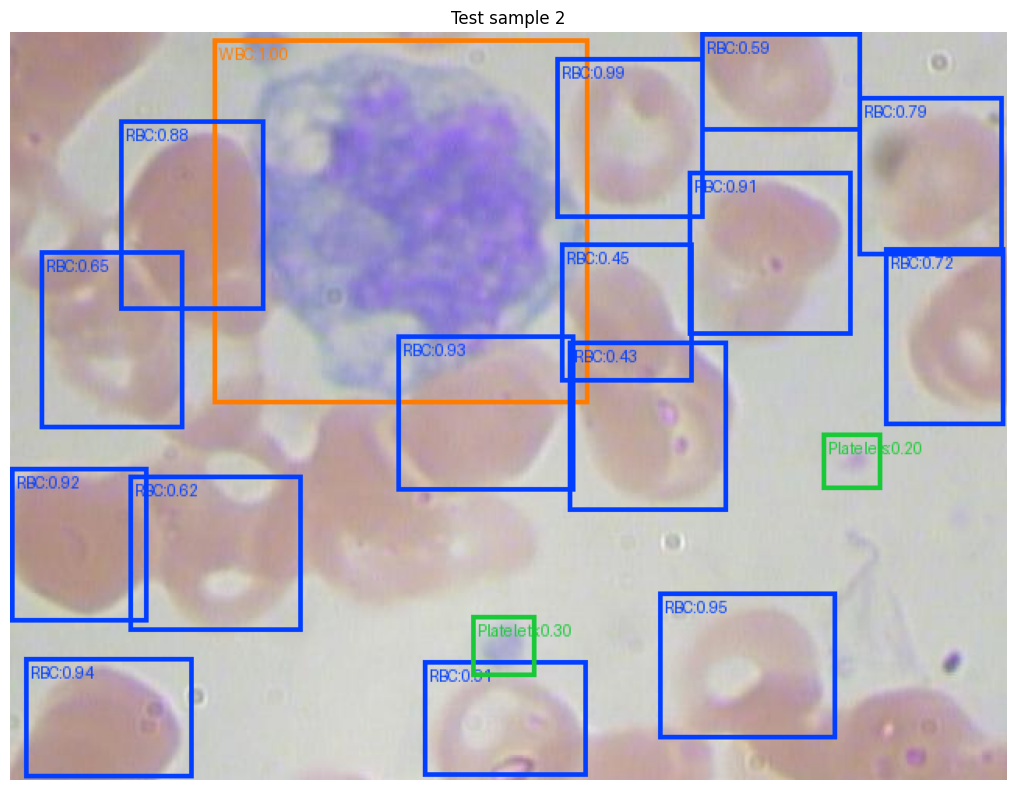

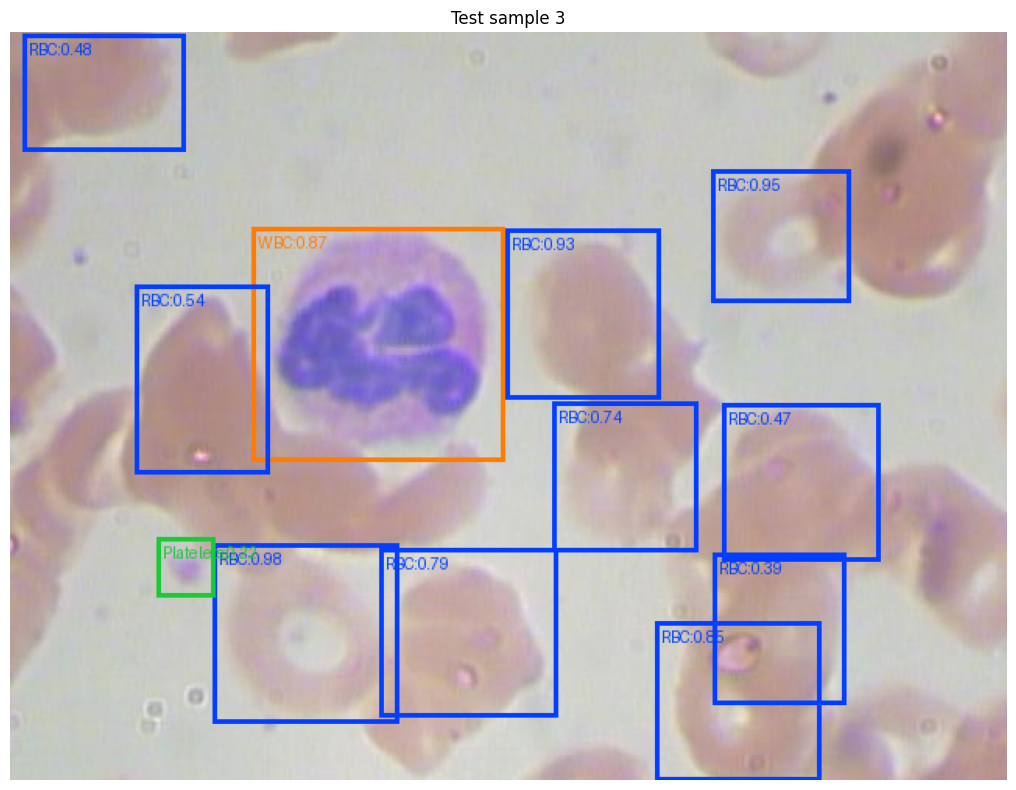

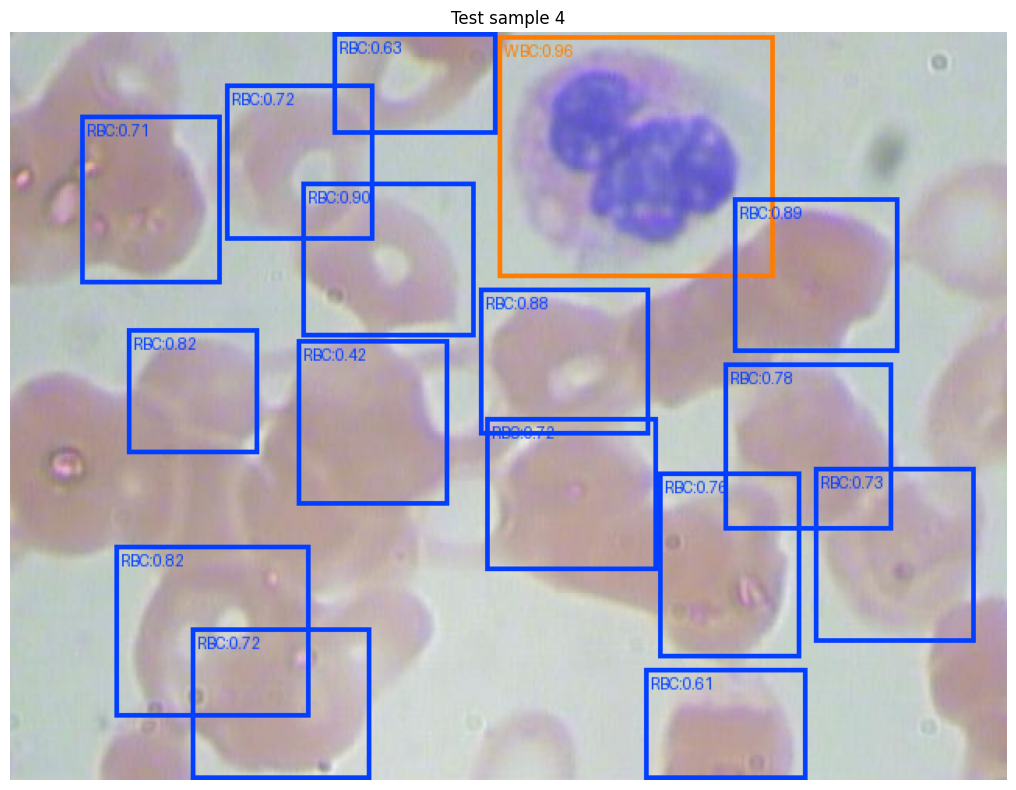

In [29]:
# Final visualization cell: static output via Matplotlib + Seaborn
from torchvision.utils import draw_bounding_boxes
import seaborn as sns
import matplotlib.pyplot as plt


def postprocess_for_visualization(pred):
    boxes = pred['boxes'].detach().cpu()
    scores = pred['scores'].detach().cpu()
    labels = pred['labels'].detach().cpu()

    keep_mask = torch.zeros_like(scores, dtype=torch.bool)
    for cls_id, thr in VIS_CLASS_THRESH.items():
        cls_keep = (labels == cls_id) & (scores >= thr)
        keep_mask |= cls_keep

    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    labels = labels[keep_mask]

    if boxes.numel() == 0:
        return boxes, scores, labels

    order = torch.argsort(scores, descending=True)[:VIS_MAX_DETECTIONS]
    return boxes[order], scores[order], labels[order]


# Seaborn palette -> RGB colors for torchvision drawing
palette = sns.color_palette('bright', 3)
class_colors = {
    1: tuple(int(255 * c) for c in palette[0]),
    2: tuple(int(255 * c) for c in palette[1]),
    3: tuple(int(255 * c) for c in palette[2]),
}

best_model.eval()
num_vis = 5

for i in range(num_vis):
    image, _ = test_ds[i]
    with torch.no_grad():
        pred = best_model([image.to(device)])[0]

    boxes, scores, labels = postprocess_for_visualization(pred)

    vis = (image * 255).to(torch.uint8)
    if boxes.numel() > 0:
        labels_list = labels.tolist()
        texts = [f"{IDX_TO_CLASS.get(lbl, lbl)}:{sc:.2f}" for lbl, sc in zip(labels_list, scores.tolist())]
        colors = [class_colors.get(lbl, (255, 255, 255)) for lbl in labels_list]
        vis = draw_bounding_boxes(vis, boxes, labels=texts, colors=colors, width=3)

    vis_np = vis.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(12, 8))
    plt.imshow(vis_np)
    plt.title(f'Test sample {i}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()